# 02 — Hyperparameter GridSearch

TimeSeriesSplit CV для Ridge, ElasticNet, RF, XGBoost.

**Запусти `main.py` сначала** (нужны данные).

In [1]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## How to read this notebook
This notebook tunes model hyperparameters with time-series-aware validation. The goal is not to maximize in-sample fit, but to find stable out-of-sample settings for dependency forecasting.

In [2]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sys, os, warnings


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from thesis_app.pipeline import load_config, build_paths, fetch_prices, compute_returns, build_target, build_features

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg   = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(ROOT)
tickers = cfg['assets']['crypto'] + cfg['assets']['traditional']
prices  = fetch_prices(paths, tickers, cfg['start_date'], cfg.get('end_date'))
rets    = compute_returns(paths, prices)
print('Data ready:', rets.shape)


Re-downloading: cached date range does not cover config dates.


[                       0%                       ]

[**************        29%                       ]  2 of 7 completed

[********************* 43%                       ]  3 of 7 completed

[**********************57%**                     ]  4 of 7 completed

[**********************71%*********              ]  5 of 7 completed

[**********************86%****************       ]  6 of 7 completed

[*********************100%***********************]  7 of 7 completed

Saved prices: D:\clear\data\raw\prices.csv shape=(3053, 7)
Data ready: (3052, 7)


In [3]:
# ── Select pair and window ────────────────────────────────────────────
BASE   = 'BTC-USD'
OTHER  = '^GSPC'
WINDOW = 30
HORIZON = 1
USE_FISHER = True
N_SPLITS = 5

y = build_target(rets, BASE, OTHER, WINDOW, HORIZON, USE_FISHER)
X = build_features(rets, WINDOW, y, BASE, OTHER, HORIZON)
y = y.loc[X.index]
Xv, yv = X.values, y.values

MIN_TRAIN = int(cfg['min_train_size'])
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
valid_splits = [(tr, te) for tr, te in tscv.split(Xv) if len(tr) >= MIN_TRAIN]
print(f'X={X.shape}, y={y.shape}, valid folds={len(valid_splits)}')
print('Features:', list(X.columns))


X=(2961, 32), y=(2961,), valid folds=4
Features: ['dep_lag1', 'dep_lag2', 'dep_lag5', 'dep_lag10', 'dep_lag20', 'dep_lag60', 'dep_mom_5', 'dep_mom_20', 'dep_zscore', 'vol_base', 'vol_other', 'vol_base_60', 'vol_other_60', 'vol_ratio', 'r_base_lag1', 'r_other_lag1', 'r_base_lag2', 'r_other_lag2', 'r_base_lag5', 'r_other_lag5', 'r_base_lag10', 'r_other_lag10', 'r_base_lag20', 'r_other_lag20', 'mean_base', 'mean_other', 'abs_spread', 'abs_spread_20', 'corr_diff', 'corr_short_mom', 'r_base_sq_lag1', 'r_other_sq_lag1']


In [4]:
# ── GridSearch: Ridge ─────────────────────────────────────────────
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
ridge_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

gs_ridge = GridSearchCV(ridge_pipe, ridge_grid, cv=valid_splits,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_ridge.fit(Xv, yv)
print(f'Ridge  best: {gs_ridge.best_params_}  CV-RMSE={-gs_ridge.best_score_:.4f}')


Ridge  best: {'model__alpha': 0.001}  CV-RMSE=0.0632


In [5]:
# ── GridSearch: ElasticNet ────────────────────────────────────────
en_pipe = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(max_iter=5000))])
en_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0], 'model__l1_ratio': [0.1, 0.5, 0.9, 1.0]}

gs_en = GridSearchCV(en_pipe, en_grid, cv=valid_splits,
                     scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_en.fit(Xv, yv)
print(f'ElasticNet best: {gs_en.best_params_}  CV-RMSE={-gs_en.best_score_:.4f}')


ElasticNet best: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}  CV-RMSE=0.0633


In [6]:
# ── GridSearch: RandomForest ──────────────────────────────────────
rf_grid = {'n_estimators': [200, 400], 'max_depth': [4, 6, 8, None], 'min_samples_leaf': [1, 5, 10]}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_grid,
                     cv=valid_splits, scoring='neg_root_mean_squared_error', n_jobs=1, verbose=1)
gs_rf.fit(Xv, yv)
print(f'RF best: {gs_rf.best_params_}  CV-RMSE={-gs_rf.best_score_:.4f}')


Fitting 4 folds for each of 24 candidates, totalling 96 fits


RF best: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 400}  CV-RMSE=0.0904


In [7]:
# ── GridSearch: XGBoost ───────────────────────────────────────────
XGB_GS_DONE = False
try:
    import xgboost as xgb
    device = cfg.get('xgb_device', 'cuda')
    try:
        xgb_base = xgb.XGBRegressor(device=device, verbosity=0, random_state=42)
    except TypeError:
        xgb_base = xgb.XGBRegressor(tree_method='gpu_hist' if device=='cuda' else 'hist',
                                      verbosity=0, random_state=42)
    xgb_grid = {
        'n_estimators': [300, 600, 1000],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.9],
        'colsample_bytree': [0.7, 0.9],
    }
    gs_xgb = GridSearchCV(xgb_base, xgb_grid, cv=valid_splits,
                          scoring='neg_root_mean_squared_error', n_jobs=1, verbose=1)
    gs_xgb.fit(Xv, yv)
    print(f'XGB best: {gs_xgb.best_params_}  CV-RMSE={-gs_xgb.best_score_:.4f}')
    XGB_GS_DONE = True
except Exception as e:
    print(f'XGB GridSearch failed: {e}')


Fitting 4 folds for each of 108 candidates, totalling 432 fits


XGB best: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}  CV-RMSE=0.0919


In [8]:
# ── Summary table ───────────────────────────────────────────────
results = [
    {'model': 'Ridge',      'best_params': str(gs_ridge.best_params_), 'cv_rmse': -gs_ridge.best_score_},
    {'model': 'ElasticNet', 'best_params': str(gs_en.best_params_),    'cv_rmse': -gs_en.best_score_},
    {'model': 'RF',         'best_params': str(gs_rf.best_params_),    'cv_rmse': -gs_rf.best_score_},
]
if XGB_GS_DONE:
    results.append({'model': 'XGB', 'best_params': str(gs_xgb.best_params_), 'cv_rmse': -gs_xgb.best_score_})

gs_df = pd.DataFrame(results).sort_values('cv_rmse')
gs_df['pair'] = f'{BASE}_vs_{OTHER}'
gs_df['window'] = WINDOW
gs_df.to_csv(os.path.join(paths.results, f'gridsearch_{BASE}_{OTHER}_w{WINDOW}.csv'), index=False)
display(gs_df)


,model,best_params,cv_rmse,pair,window
0,Ridge,{'model__alpha': 0.001},0.063195,BTC-USD_vs_^GSPC,30
1,ElasticNet,"{'model__alpha': 0.001, 'model__l1_ratio': 0.1}",0.063319,BTC-USD_vs_^GSPC,30
2,RF,"{'max_depth': None, 'min_samples_leaf': 10, 'n...",0.090446,BTC-USD_vs_^GSPC,30
3,XGB,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.091875,BTC-USD_vs_^GSPC,30


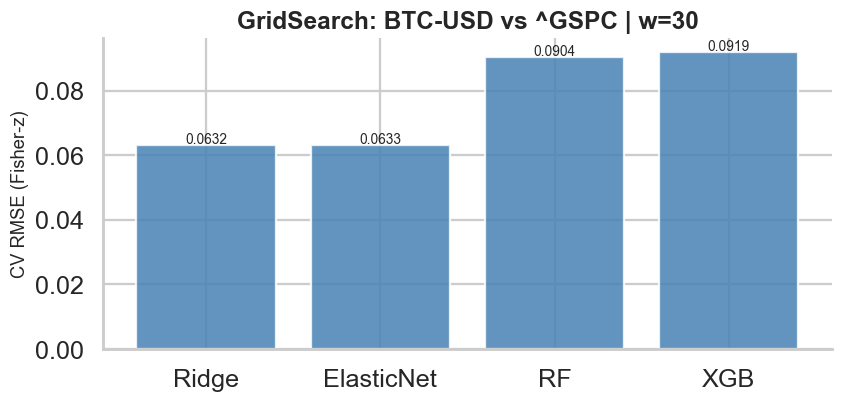

In [9]:
# ── CV RMSE bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(gs_df['model'], gs_df['cv_rmse'], color='steelblue', alpha=0.85)
ax.set_ylabel('CV RMSE (Fisher-z)')
ax.set_title(f'GridSearch: {BASE} vs {OTHER} | w={WINDOW}')
for i, row in gs_df.reset_index(drop=True).iterrows():
    ax.text(i, row['cv_rmse'] + 0.0005, f"{row['cv_rmse']:.4f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'gridsearch_cv_rmse_{BASE}_{OTHER}_w{WINDOW}.png'), dpi=130)
plt.show()


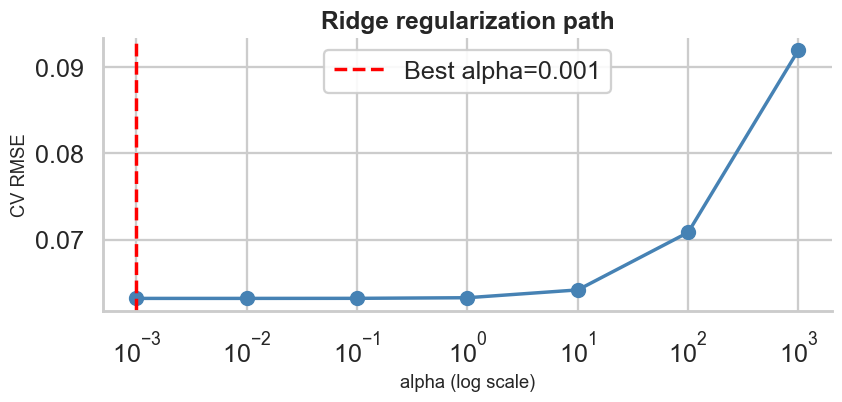

In [10]:
# ── Ridge regularization path ─────────────────────────────────────
alphas = [float(a) for a in gs_ridge.cv_results_['param_model__alpha']]
scores = -gs_ridge.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, scores, 'o-', color='steelblue')
best_a = float(gs_ridge.best_params_['model__alpha'])
ax.axvline(best_a, color='red', ls='--', label=f'Best alpha={best_a}')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('CV RMSE')
ax.set_title('Ridge regularization path')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'ridge_regularization_path.png'), dpi=130)
plt.show()


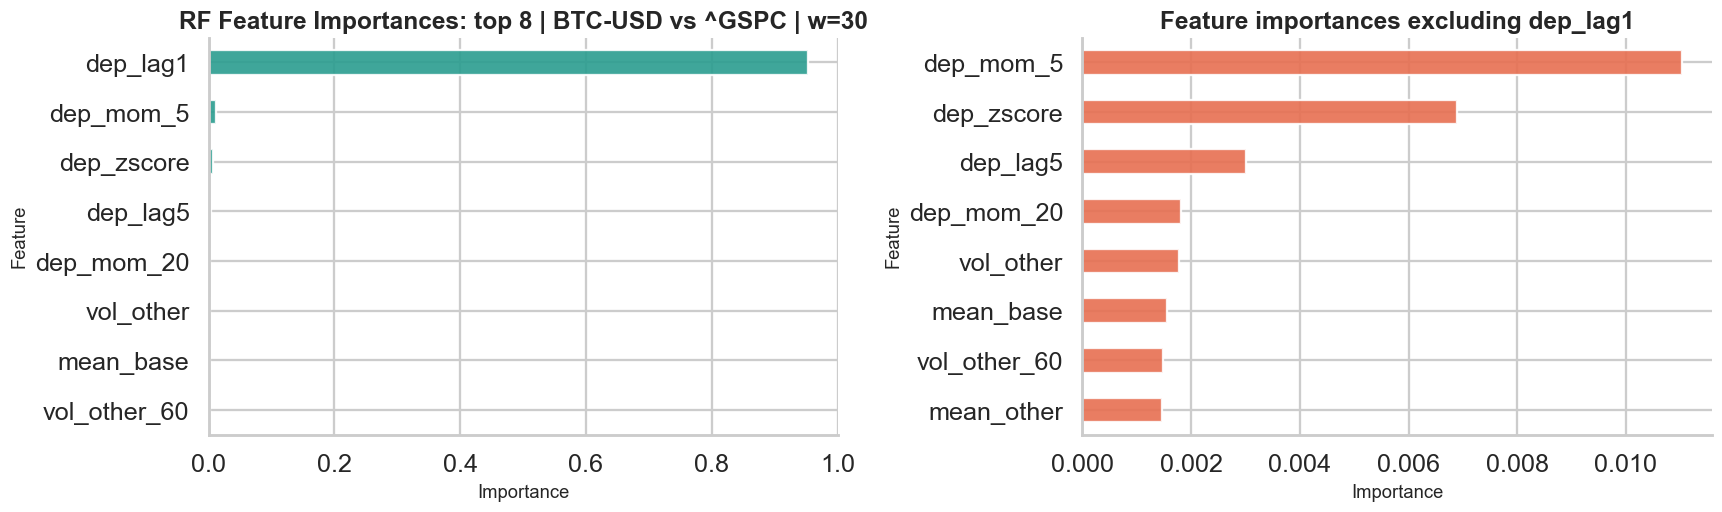

Top feature importances:
dep_lag1         0.9528
dep_mom_5        0.0110
dep_zscore       0.0069
dep_lag5         0.0030
dep_mom_20       0.0018
vol_other        0.0018
mean_base        0.0016
vol_other_60     0.0015
mean_other       0.0015
dep_lag10        0.0014
dep_lag60        0.0013
abs_spread_20    0.0012
dtype: float64
Interpretation:
- The model places most weight on dep_lag1, which indicates strong persistence in the rolling dependency series.
- Secondary features should be interpreted as incremental refinements rather than primary drivers.
- For the thesis, this supports the conclusion that one-step-ahead dependency forecasts are dominated by autocorrelation.


In [11]:
# RF Feature Importance: readable version for thesis
best_rf = gs_rf.best_estimator_
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: top features overall
top_n = min(8, len(feat_imp))
feat_imp.head(top_n).sort_values().plot(kind='barh', ax=axes[0], color='#2a9d8f', alpha=0.9)
axes[0].set_title(f'RF Feature Importances: top {top_n} | {BASE} vs {OTHER} | w={WINDOW}')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

# Panel B: same plot without the dominant persistence feature
feat_imp_wo_main = feat_imp.drop('dep_lag1', errors='ignore')
if not feat_imp_wo_main.empty:
    top_n_wo = min(8, len(feat_imp_wo_main))
    feat_imp_wo_main.head(top_n_wo).sort_values().plot(kind='barh', ax=axes[1], color='#e76f51', alpha=0.9)
    axes[1].set_title('Feature importances excluding dep_lag1')
    axes[1].set_xlabel('Importance')
    axes[1].set_ylabel('Feature')
else:
    axes[1].text(0.5, 0.5, 'No features remain after removing dep_lag1', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'rf_feature_importance_{BASE}_{OTHER}_w{WINDOW}_readable.png'), dpi=140)
plt.show()

print('Top feature importances:')
print(feat_imp.head(12).round(4))
print('Interpretation:')
print('- The model places most weight on dep_lag1, which indicates strong persistence in the rolling dependency series.')
print('- Secondary features should be interpreted as incremental refinements rather than primary drivers.')
print('- For the thesis, this supports the conclusion that one-step-ahead dependency forecasts are dominated by autocorrelation.')


In [12]:
print('GridSearch complete.')

GridSearch complete.
